<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:

!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

df = pd.read_csv("survey-data.csv")

df.head()

!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

df = pd.read_csv("survey-data.csv")

df.head()

--2026-07-03 11:00:58--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  30.7MB/s    in 5.2s    

2026-07-03 11:01:04 (29.1 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]

--2026-07-03 11:01:13--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Conne

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


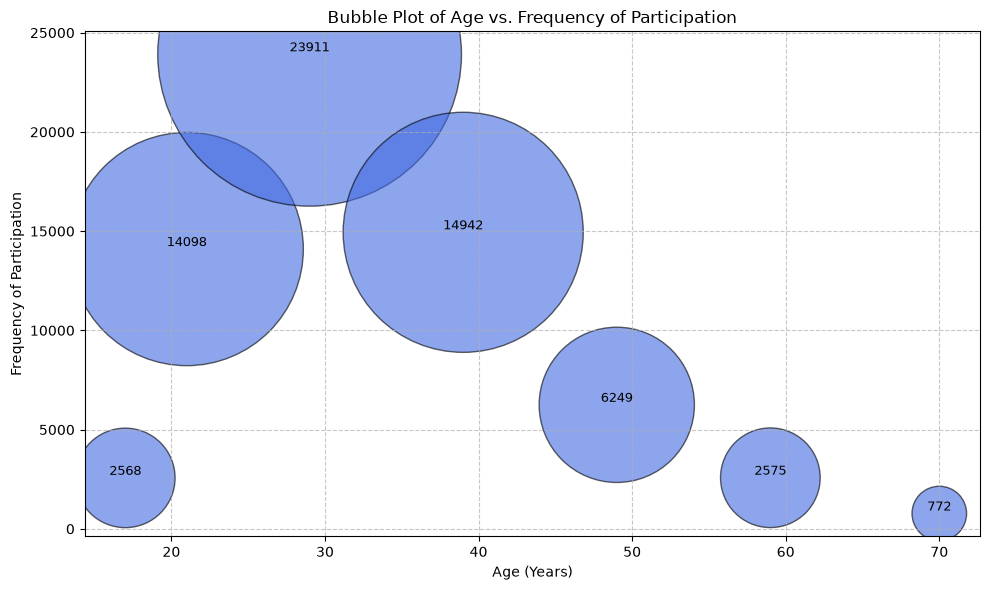

In [3]:
import sqlite3
import matplotlib.pyplot as plt
from collections import Counter

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT Age
FROM main
WHERE Age IS NOT NULL;
""")

rows = cursor.fetchall()

conn.close()

# Convert Age categories to numeric values
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

age_counter = Counter()

for (age,) in rows:
    if age in age_mapping:
        age_counter[age_mapping[age]] += 1

ages = sorted(age_counter.keys())
frequency = [age_counter[age] for age in ages]

bubble_sizes = [count * 2 for count in frequency]

plt.figure(figsize=(10, 6))

plt.scatter(
    ages,
    frequency,
    s=bubble_sizes,
    color="royalblue",
    alpha=0.6,
    edgecolors="black"
)

for x, y in zip(ages, frequency):
    plt.text(x, y, str(y), fontsize=9, ha='center', va='bottom')

plt.title("Bubble Plot of Age vs. Frequency of Participation")
plt.xlabel("Age (Years)")
plt.ylabel("Frequency of Participation")
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


In [ ]:

%pip install matplotlib

import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT CompTotal, JobSatPoints_6
FROM main
WHERE CompTotal IS NOT NULL
AND JobSatPoints_6 IS NOT NULL;
""")

rows = cursor.fetchall()

conn.close()

compensation = []
job_satisfaction = []
bubble_sizes = []

for comp, sat in rows:
    try:
        comp = float(comp)
        sat = float(sat)

     
        if comp > 0:
            compensation.append(comp)
            job_satisfaction.append(sat)

            # Scale bubble size
            bubble_sizes.append(max(comp / 1000, 10))

    except (ValueError, TypeError):
        continue

plt.figure(figsize=(12, 7))

plt.scatter(
    compensation,
    job_satisfaction,
    s=bubble_sizes,
    color="royalblue",
    alpha=0.5,
    edgecolors="black"
)

plt.xscale("log")

plt.title("Bubble Plot of Compensation vs. Job Satisfaction")
plt.xlabel("CompTotal (Log Scale)")
plt.ylabel("Job Satisfaction (JobSatPoints_6)")

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 149.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 128.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 181.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 144.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



In [ ]:
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT YearsCodePro, CompTotal, JobSatPoints_6
FROM main
WHERE YearsCodePro IS NOT NULL
AND CompTotal IS NOT NULL
AND JobSatPoints_6 IS NOT NULL;
""")

rows = cursor.fetchall()

conn.close()

experience = []
compensation = []
bubble_sizes = []

for years, comp, sat in rows:
    try:
        if years == "Less than 1 year":
            years = 0.5
        elif years == "More than 50 years":
            years = 51
        else:
            years = float(years)

        comp = float(comp)
        sat = float(sat)

        if comp > 0:
            experience.append(years)
            compensation.append(comp)

            bubble_sizes.append(sat * 40)

    except (ValueError, TypeError):
        continue

plt.figure(figsize=(12, 7))

plt.scatter(
    experience,
    compensation,
    s=bubble_sizes,
    alpha=0.6,
    color="royalblue",
    edgecolors="black"
)

plt.yscale("log")

plt.title("Bubble Plot: Work Experience vs Compensation")
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("CompTotal (Log Scale)")

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


In [ ]:
import sqlite3
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT DatabaseHaveWorkedWith, JobSatPoints_6
FROM main
WHERE DatabaseHaveWorkedWith IS NOT NULL
AND JobSatPoints_6 IS NOT NULL;
""")

rows = cursor.fetchall()

conn.close()

database_counter = Counter()

for databases, _ in rows:
    for db in databases.split(";"):
        database_counter[db.strip()] += 1

top_databases = [db for db, _ in database_counter.most_common(10)]

db_positions = {db: i for i, db in enumerate(top_databases)}

frequency = defaultdict(int)

for databases, jobsat in rows:
    try:
        jobsat = int(float(jobsat))

        for db in databases.split(";"):
            db = db.strip()

            if db in db_positions and 1 <= jobsat <= 6:
                frequency[(db, jobsat)] += 1

    except (ValueError, TypeError):
        continue

x = []
y = []
sizes = []

for (db, jobsat), count in frequency.items():
    x.append(db_positions[db])
    y.append(jobsat)
    sizes.append(count * 5)  

plt.figure(figsize=(12, 7))

plt.scatter(
    x,
    y,
    s=sizes,
    color="royalblue",
    alpha=0.6,
    edgecolors="black"
)

plt.xticks(
    ticks=range(len(top_databases)),
    labels=top_databases,
    rotation=45,
    ha="right"
)

plt.yticks([1, 2, 3, 4, 5, 6])

plt.title("Bubble Plot of Preferred Databases vs. Job Satisfaction")
plt.xlabel("Preferred Databases")
plt.ylabel("Job Satisfaction (JobSatPoints_6)")

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

df = df[["DevType", "ConvertedCompYearly", "JobSat"]].dropna()

df["DevType"] = df["DevType"].str.split(";")

df_expanded = df.explode("DevType")

df_expanded["DevType"] = df_expanded["DevType"].str.strip()

median compensation (more robust than mean)
average job satisfaction
number of respondents
role_stats = (
    df_expanded
    .groupby("DevType")
    .agg(
        MedianComp=("ConvertedCompYearly", "median"),
        AvgJobSat=("JobSat", "mean"),
        Respondents=("JobSat", "count")
    )
    .reset_index()
)
plt.figure(figsize=(14, 7))

x = range(len(role_stats))

plt.scatter(
    x,
    role_stats["MedianComp"],
    s=role_stats["AvgJobSat"] * 50,  
    alpha=0.6,
    c=role_stats["AvgJobSat"],       
    cmap="viridis",
    edgecolors="black"
)

plt.xticks(x, role_stats["DevType"], rotation=90)

plt.title("Compensation Across Developer Roles (Bubble = Job Satisfaction)")
plt.xlabel("Developer Role (DevType)")
plt.ylabel("Median Yearly Compensation")

plt.colorbar(label="Avg Job Satisfaction")

plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = df[["Age", "NEWCollabToolsHaveWorkedWith"]].dropna()

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 18, 24, 34, 44, 54, 100],
    labels=["<18", "18-24", "25-34", "35-44", "45-54", "55+"]
)

df["NEWCollabToolsHaveWorkedWith"] = df["NEWCollabToolsHaveWorkedWith"].str.split(";")

df_expanded = df.explode("NEWCollabToolsHaveWorkedWith")

df_expanded["NEWCollabToolsHaveWorkedWith"] = df_expanded["NEWCollabToolsHaveWorkedWith"].str.strip()

tool_age = (
    df_expanded
    .groupby(["NEWCollabToolsHaveWorkedWith", "AgeGroup"])
    .size()
    .reset_index(name="Frequency")
)

plt.figure(figsize=(14, 7))

tools = tool_age["NEWCollabToolsHaveWorkedWith"].unique()
ages = tool_age["AgeGroup"].unique()

x_map = {t: i for i, t in enumerate(tools)}
y_map = {a: i for i, a in enumerate(ages)}

plt.scatter(
    tool_age["NEWCollabToolsHaveWorkedWith"].map(x_map),
    tool_age["AgeGroup"].map(y_map),
    s=tool_age["Frequency"] * 8,   
    alpha=0.6,
    edgecolors="black"
)

plt.xticks(range(len(tools)), tools, rotation=90)
plt.yticks(range(len(ages)), ages)

plt.title("Collaboration Tools Usage Across Age Groups")
plt.xlabel("Collaboration Tools")
plt.ylabel("Age Group")

plt.tight_layout()
plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



In [ ]:

import pandas as pd
import matplotlib.pyplot as plt


df = df[["WebframeWantToWorkWith", "JobSat"]].dropna()

df["WebframeWantToWorkWith"] = df["WebframeWantToWorkWith"].str.split(";")

df_expanded = df.explode("WebframeWantToWorkWith")

df_expanded["WebframeWantToWorkWith"] = df_expanded["WebframeWantToWorkWith"].str.strip()

wf_job = (
    df_expanded
    .groupby(["WebframeWantToWorkWith", "JobSat"])
    .size()
    .reset_index(name="Respondents")
)

plt.figure(figsize=(14, 7))

frameworks = wf_job["WebframeWantToWorkWith"].unique()
jobs = wf_job["JobSat"].unique()

x_map = {wf: i for i, wf in enumerate(frameworks)}
y_map = {js: i for i, js in enumerate(jobs)}

plt.scatter(
    wf_job["WebframeWantToWorkWith"].map(x_map),
    wf_job["JobSat"].map(y_map),
    s=wf_job["Respondents"] * 10,  
    alpha=0.6,
    edgecolors="black"
)

plt.xticks(range(len(frameworks)), frameworks, rotation=90)
plt.yticks(range(len(jobs)), jobs)

plt.title("Web Framework Preferences vs Job Satisfaction")
plt.xlabel("Web Framework (Want to Work With)")
plt.ylabel("Job Satisfaction")

plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



In [ ]:
import sqlite3
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT Country, LanguageAdmired
FROM main
WHERE Country IS NOT NULL
AND LanguageAdmired IS NOT NULL;
""")

rows = cursor.fetchall()

conn.close()

country_counter = Counter()

technology_counter = Counter()

for country, technologies in rows:
    country_counter[country] += 1

    for tech in technologies.split(";"):
        technology_counter[tech.strip()] += 1


top_countries = [country for country, _ in country_counter.most_common(10)]
top_technologies = [tech for tech, _ in technology_counter.most_common(10)]

country_positions = {country: i for i, country in enumerate(top_countries)}
technology_positions = {tech: i for i, tech in enumerate(top_technologies)}

frequency = defaultdict(int)

for country, technologies in rows:
    if country not in country_positions:
        continue

    for tech in technologies.split(";"):
        tech = tech.strip()

        if tech in technology_positions:
            frequency[(country, tech)] += 1


x = []
y = []
sizes = []

for (country, tech), count in frequency.items():
    x.append(country_positions[country])
    y.append(technology_positions[tech])
    sizes.append(count * 5)  

plt.figure(figsize=(14, 8))

plt.scatter(
    x,
    y,
    s=sizes,
    color="royalblue",
    alpha=0.6,
    edgecolors="black"
)

plt.xticks(
    ticks=range(len(top_countries)),
    labels=top_countries,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=range(len(top_technologies)),
    labels=top_technologies
)

plt.title("Bubble Plot for Admired Technologies Across Countries")
plt.xlabel("Country")
plt.ylabel("Admired Technologies")

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
